In [1]:
#Performs necessary imports
import pandas as pd
import os
import numpy as np
import itertools
from collections import Counter


In [2]:
cycles = 6              # number of election cycles, counting back from last_election
maxbalance = 1000      # max |vote_balance| to keep (set high = keep ~all combinations)
max_balchange = 1000   # max |balance_change| to keep (set high = keep ~all combinations)
comb_max = 5             # max combination size (3-5)
last_election = 2020


In [3]:
#Reads data from a public file containing the data from the past 6 elections
#Changed the vote allocation system to hamilton/largest remainder method to avoid rounding problems
#file_path = 'https://adityagarg9.github.io/Voter-Realignment-Data/VoterRealignmentData.csv'

#electiondata = pd.read_csv(file_path).fillna(0)
electiondata = pd.read_csv('election_data_2000_2024.csv').fillna(0)
#electiondata.head()

electiondata['sum_voters'] = electiondata[['POPULAR VOTE: D', 'POPULAR VOTE: R']].sum(axis=1) #Creates a column with the total number of votes for later divion purposes

electiondata['DEMOCRAT PERCENTAGE'] = ((electiondata['POPULAR VOTE: D']/(electiondata['sum_voters']))*100) #Calculates the percentage of these votes won by the democrats

electiondata['REPUBLICAN PERCENTAGE'] = ((electiondata['POPULAR VOTE: R']/(electiondata['sum_voters']))*100) #Calculates the percentage of these votes won by the republicans

electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'] = (electiondata['TOTAL ELECTORAL VOTES: D'] + electiondata['TOTAL ELECTORAL VOTES: R']) #Calculates the total electoral votes for each state to later help determine the change from winner-take-all to proportional.

# Exact (unrounded) electoral-vote quota each party has earned in the state.
# Note the /100: DEMOCRAT PERCENTAGE is on a 0-100 scale, so we convert back to a share first.
electiondata['q_dem'] = (electiondata['DEMOCRAT PERCENTAGE']   / 100) * electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'] #Calculates the number
electiondata['q_rep'] = (electiondata['REPUBLICAN PERCENTAGE'] / 100) * electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'] #Calculates the number

# Largest-remainder (Hamilton) allocation, done vectorially across all rows.
# Give each party the whole votes it clearly earned (the floor of its quota)...
f_dem = np.floor(electiondata['q_dem']).astype(int)
f_rep = np.floor(electiondata['q_rep']).astype(int)

# ...then work out the single leftover vote (0 or 1 for two parties).
total_ev  = electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'].round().astype(int)
remaining = total_ev - f_dem - f_rep     # 0 or 1 for two parties

# leftover seat goes to the larger fractional remainder (ties -> D)
dem_gets_leftover = (remaining > 0) & ((electiondata['q_dem'] - f_dem) >= (electiondata['q_rep'] - f_rep))

electiondata['DEMOCRAT REALLOCATED']   = f_dem + np.where(dem_gets_leftover, remaining, 0) #Reallocates the electoral votes for the democrats from winner-take-all to proportional based on popular vote percentage.

electiondata['REPUBLICAN REALLOCATED'] = f_rep + np.where((remaining > 0) & ~dem_gets_leftover, remaining, 0) #Reallocates the electoral votes for the republicans from winner-take-all to proportional based on popular vote percentage.

electiondata['DEMOCRAT CHANGE'] = electiondata['DEMOCRAT REALLOCATED'] - electiondata['TOTAL ELECTORAL VOTES: D'] #Calculates the change in electoral votes for democrats for each state from the winner-take-all system to the proportional system

electiondata['REPUBLICAN CHANGE'] = electiondata['REPUBLICAN REALLOCATED'] - electiondata['TOTAL ELECTORAL VOTES: R'] #Calculates the change in electoral votes for republicans for each state from the winner-take-all system to the proportional system

electiondata.head()

,YEAR,STATE,TOTAL ELECTORAL VOTES: D,TOTAL ELECTORAL VOTES: R,POPULAR VOTE: D,POPULAR VOTE: R,POPULAR VOTE: All Others,sum_voters,DEMOCRAT PERCENTAGE,REPUBLICAN PERCENTAGE,TOTAL ELECTORAL VOTES FOR EACH STATE,q_dem,q_rep,DEMOCRAT REALLOCATED,REPUBLICAN REALLOCATED,DEMOCRAT CHANGE,REPUBLICAN CHANGE
0,2020,CA,55.0,0.0,11110639,6006518,384223,17117157,64.909371,35.090629,55.0,35.700154,19.299846,36,19,-19.0,19.0
1,2020,NY,29.0,0.0,5244886,3251997,119978,8496883,61.727177,38.272823,29.0,17.900881,11.099119,18,11,-11.0,11.0
2,2020,PA,20.0,0.0,3458229,3377674,101073,6835903,50.589205,49.410795,20.0,10.117841,9.882159,10,10,-10.0,10.0
3,2020,GA,16.0,0.0,2473633,2461854,64473,4935487,50.119330,49.880670,16.0,8.019093,7.980907,8,8,-8.0,8.0
4,2020,IL,20.0,0.0,3471915,2446891,114938,5918806,58.659044,41.340956,20.0,11.731809,8.268191,12,8,-8.0,8.0


In [4]:
#This dataframe gives an overview of the cycles
dem_total = electiondata.groupby('YEAR')['TOTAL ELECTORAL VOTES: D'].sum().reset_index()

dem_total.columns = ['YEAR', 'TOTAL_DEM_VOTES']

rep_total = electiondata.groupby('YEAR')['TOTAL ELECTORAL VOTES: R'].sum().reset_index()

rep_total.columns = ['YEAR', 'TOTAL_REP_VOTES']

popular_d = electiondata.groupby('YEAR')['POPULAR VOTE: D'].sum().reset_index()

popular_r = electiondata.groupby('YEAR')['POPULAR VOTE: R'].sum().reset_index()

allothers = electiondata.groupby('YEAR')['POPULAR VOTE: All Others'].sum().reset_index()

merged_df = dem_total.merge(rep_total, on='YEAR')\
                     .merge(popular_d, on='YEAR')\
                     .merge(popular_r, on='YEAR')\
                     .merge(allothers, on='YEAR')

merged_df['DIFF'] = (merged_df['TOTAL_DEM_VOTES'] - merged_df['TOTAL_REP_VOTES'])

merged_df['WINNER'] = np.where(merged_df['DIFF'] > 0, 'D', 'R')

merged_df['VOTES_TO_WIN'] = ((merged_df['DIFF'].abs())/2)+1

merged_df['VOTES_TO_WIN'] = np.floor(merged_df['VOTES_TO_WIN'] * 1) / 1

orig_pres_results = merged_df
merged_df.head(10)

#Makes a new dataframe, showing how many electoral votes each part had after reallocation
new_dem_total = electiondata.groupby('YEAR')['DEMOCRAT REALLOCATED'].sum().reset_index()

new_dem_total.columns = ['YEAR', 'TOTAL_DEM_VOTES_REALLOCATED']

new_rep_total = electiondata.groupby('YEAR')['REPUBLICAN REALLOCATED'].sum().reset_index()

new_rep_total.columns = ['YEAR', 'TOTAL_REP_VOTES_REALLOCATED']

new_merged_df = pd.merge(new_dem_total, new_rep_total, on='YEAR')

new_merged_df.head()
merged_df.head(10)
#Votes to win is a margin of victory measure, low votes to win means that the presidential race was close

,YEAR,TOTAL_DEM_VOTES,TOTAL_REP_VOTES,POPULAR VOTE: D,POPULAR VOTE: R,POPULAR VOTE: All Others,DIFF,WINNER,VOTES_TO_WIN
0,2000,266.0,271.0,50999897,50456002,3949201,-5.0,R,3.0
1,2004,251.0,286.0,59028444,62040610,1226291,-35.0,R,18.0
2,2008,365.0,173.0,69498516,59948323,1866981,192.0,D,97.0
3,2012,332.0,206.0,65915795,60933504,2236111,126.0,D,64.0
4,2016,227.0,304.0,65853514,62984828,7830934,-77.0,R,39.0
5,2020,306.0,232.0,81283501,74223975,2922155,74.0,D,38.0
6,2024,226.0,312.0,75017613,77302580,2918109,-86.0,R,44.0


In [5]:

# =====================================================================
# STEP 4: Efficient combination-level metrics
#   - Combination index built ONCE per size r (not once per year)
#   - 'combination' stored as a Categorical (small int codes instead of
#     repeated Python tuples) -- unified across sizes via union_categoricals
#   - int32/int16/int8 dtypes instead of default int64
# =====================================================================
def compute_results_df(electiondata, comb_max, cycles, last_election=2020):
    min_year = last_election - (4 * (cycles - 1))
    electiondata = electiondata[(electiondata['YEAR'] >= min_year) & (electiondata['YEAR'] <= last_election)]
    if electiondata.empty:
        return pd.DataFrame(columns=['YEAR', 'combination', 'size', 'vote_balance',
                                     'balance_prop', 'balance_change', 'chg_dem', 'chg_rep'])

    combo_cache = {}       # r -> {'idx', 'cat_dtype', 'codes'} -- built once per size
    frames_by_size = {}    # r -> list of per-year DataFrames

    for year, ydf in electiondata.groupby('YEAR'):
        ydf = ydf.sort_values('STATE')
        states = ydf['STATE'].to_numpy()
        dem  = ydf['TOTAL ELECTORAL VOTES: D'].to_numpy()
        rep  = ydf['TOTAL ELECTORAL VOTES: R'].to_numpy()
        pdem = ydf['DEMOCRAT REALLOCATED'].to_numpy()
        prep = ydf['REPUBLICAN REALLOCATED'].to_numpy()
        n = len(states)

        for r in range(3, comb_max + 1):
            if r > n:
                break

            if r not in combo_cache:
                idx = np.fromiter(
                    itertools.chain.from_iterable(itertools.combinations(range(n), r)),
                    dtype=np.int32
                ).reshape(-1, r)
                combos_list = [tuple(states[row]) for row in idx]
                cat_dtype = pd.CategoricalDtype(categories=combos_list, ordered=False)
                combo_cache[r] = {
                    'idx': idx,
                    'cat_dtype': cat_dtype,
                    'codes': np.arange(len(combos_list), dtype=np.int32),
                }
            cache = combo_cache[r]
            idx = cache['idx']

            d   = dem[idx].sum(axis=1)
            rp  = rep[idx].sum(axis=1)
            pd_ = pdem[idx].sum(axis=1)
            pr  = prep[idx].sum(axis=1)

            balance      = np.abs(d - rp).astype(np.int32)
            balance_prop = np.abs(pd_ - pr).astype(np.int32)
            flip = (d > rp) != (pd_ > pr)
            balance_change = np.where(flip, balance + balance_prop, np.abs(balance - balance_prop)).astype(np.int32)

            combo_col = pd.Categorical.from_codes(cache['codes'], dtype=cache['cat_dtype'])

            df_chunk = pd.DataFrame({
                'YEAR': np.int16(year),
                'combination': combo_col,
                'size': np.int8(r),
                'vote_balance': balance,
                'balance_prop': balance_prop,
                'balance_change': balance_change,
                'chg_dem': (pd_ - d).astype(np.int32),
                'chg_rep': (pr - rp).astype(np.int32),
            })
            frames_by_size.setdefault(r, []).append(df_chunk)

    # Concatenate WITHIN each size first (same categories -> stays Categorical, cheap)
    per_size_dfs = {r: pd.concat(fr, ignore_index=True) for r, fr in frames_by_size.items()}

    # Combine across sizes with union_categoricals so it doesn't fall back to 'object'
    combo_union = pd.api.types.union_categoricals(
        [df['combination'] for df in per_size_dfs.values()], sort_categories=False
    )
    other_cols = pd.concat(
        [df.drop(columns=['combination']) for df in per_size_dfs.values()], ignore_index=True
    )
    other_cols['combination'] = pd.Categorical(combo_union)
    return other_cols[['YEAR', 'combination', 'size', 'vote_balance', 'balance_prop',
                        'balance_change', 'chg_dem', 'chg_rep']]

results_df = compute_results_df(electiondata, comb_max, cycles, last_election)

# =====================================================================
# STEP 5: Filter + proportional-stability check, streamlined --
#   no final_states DataFrame is ever built; only a small per-combination
#   summary table (combo_summary) is needed for the reported counts.
# =====================================================================
min_year = last_election - (4 * (cycles - 1))

filtered_results = results_df[
    (results_df['YEAR'] >= min_year) &
    (results_df['vote_balance'].abs() <= maxbalance) &
    (results_df['balance_change'].abs() <= max_balchange)
]

filtered_results = pd.merge(filtered_results, orig_pres_results, on='YEAR')
filtered_results['proportional_stable_bool'] = np.where(
    (filtered_results['WINNER'] == "D") & (filtered_results['chg_rep'] > filtered_results['VOTES_TO_WIN']),
    False,
    np.where(
        (filtered_results['WINNER'] == "R") & (filtered_results['chg_dem'] > filtered_results['VOTES_TO_WIN']),
        False,
        True
    )
)

combo_summary = filtered_results.groupby('combination', observed=True).agg(
    all_stable=('proportional_stable_bool', 'all'),
    n=('proportional_stable_bool', 'size'),
    size=('size', 'first'),
)
qualifying_summary = combo_summary[(combo_summary['all_stable']) & (combo_summary['n'] >= cycles)]

# Overall (pooled across sizes)
proportional_stable_true_count = int(qualifying_summary['n'].sum())
total_combinations = len(filtered_results)

print(f"Number of combinations with proportional_stable == True: "
      f"{proportional_stable_true_count} out of {total_combinations}")

# =====================================================================
# STEP 6:--- How many x-state combinations were proportional-stable in ALL years ---
# =====================================================================
n_years = results_df['YEAR'].nunique()
total_by_size = filtered_results.groupby('size').size()
stable_by_size = qualifying_summary.groupby('size')['n'].sum()

print(f"Proportional-stable across all {n_years} years, by combination size:")
#print("\nNumber and percentage of proportional-stable combination-rows, by size:")
for s in sorted(total_by_size.index):
    tot = int(total_by_size[s])
    stab = int(stable_by_size.get(s, 0))
    pct = stab / tot * 100 if tot else 0
    print(f"  {s}-state: {stab} of {tot} ({pct:.2f}%)")

Number of combinations with proportional_stable == True: 8946282 out of 15718710
Proportional-stable across all 6 years, by combination size:
  3-state: 75048 of 124950 (60.06%)
  4-state: 870816 of 1499400 (58.08%)
  5-state: 8000418 of 14094360 (56.76%)


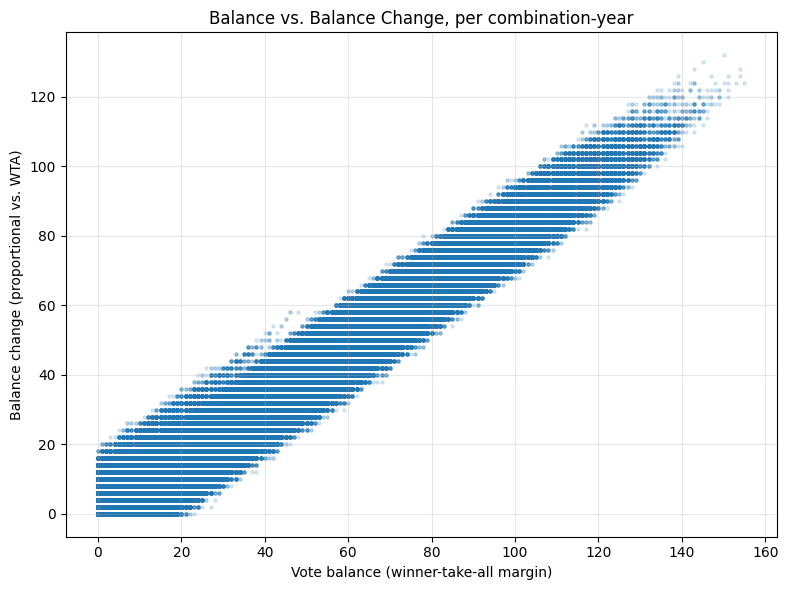

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results_df['vote_balance'], results_df['balance_change'], s=5, alpha=0.15)
ax.set_xlabel('Vote balance (winner-take-all margin)')
ax.set_ylabel('Balance change (proportional vs. WTA)')
ax.set_title('Balance vs. Balance Change, per combination-year')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('balance_vs_balance_change.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
#This is analyzing across election years. For a combination to be labeled low balance change it has to be low in each and every cycle
import numpy as np


thresholds = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
n_years = results_df['YEAR'].nunique()

# Capture the actual election years this summary covers, so the chart can label itself correctly
years_covered = sorted(results_df['YEAR'].unique())
year_min = int(years_covered[0])
year_max = int(years_covered[-1])
year_range_label = f"{year_min}-{year_max}"

if 'size' not in results_df.columns:
    results_df['size'] = results_df['combination'].map(len)

# For each combination: the worst (max) balance_change across all years it appears in,
# how many years it appears in (n), and its size.
per_combo = results_df.groupby('combination').agg(
    max_bc=('balance_change', 'max'),
    n=('balance_change', 'size'),
    size=('size', 'first')
)

# Only keep combinations that actually appear in every one of the n_years cycles --
# same guard as before, so a combination missing from some years doesn't count.
per_combo = per_combo[per_combo['n'] == n_years]

records = []
for size, group in per_combo.groupby('size'):
    total = len(group)
    if total == 0:
        continue
    for t in thresholds:
        # A combination "qualifies at threshold t" iff its WORST year is still <= t,
        # which is exactly the "balance_change <= t in every cycle" condition.
        count = int((group['max_bc'] <= t).sum())
        records.append({
            'size': int(size),
            'threshold': t,
            'count': count,
            'pct': round(count / total * 100, 2),
            'total': total,
            'year_min': year_min,
            'year_max': year_max,
            'year_range_label': year_range_label,
        })

summary = pd.DataFrame(records)
summary.to_csv('always_stable_cumulative_distribution_by_size.csv', index=False)

summary.head(20)

/tmp/ipykernel_2633/3689286373.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_combo = results_df.groupby('combination').agg(


,size,threshold,count,pct,total,year_min,year_max,year_range_label
0,3,1,26,0.12,20825,2000,2020,2000-2020
1,3,3,640,3.07,20825,2000,2020,2000-2020
2,3,5,1467,7.04,20825,2000,2020,2000-2020
3,3,10,4607,22.12,20825,2000,2020,2000-2020
4,3,15,7130,34.24,20825,2000,2020,2000-2020
5,3,20,10996,52.80,20825,2000,2020,2000-2020
6,3,25,13200,63.39,20825,2000,2020,2000-2020
7,3,30,15714,75.46,20825,2000,2020,2000-2020
8,3,35,16950,81.39,20825,2000,2020,2000-2020
9,3,40,18349,88.11,20825,2000,2020,2000-2020


In [8]:
#Report combinations with low balance change counts
#for combinations that stay under a given balance_change threshold in every election cycle, how often does each individual state get to participate, and what percentage of that state's possible combinations qualify?
from collections import Counter
import gc

def compute_state_frequency_lowmem(df, thresholds, all_states, label):
    n_years = df['YEAR'].nunique()

    # Capture the actual election years this analysis covers
    years_covered = sorted(df['YEAR'].unique())
    year_min = int(years_covered[0])
    year_max = int(years_covered[-1])
    year_range_label = f"{year_min}-{year_max}"

    if 'size' not in df.columns:
        df = df.copy()
        df['size'] = df['combination'].map(len)
    codes, uniques = pd.factorize(df['combination'])
    n_combos = len(uniques)
    size_arr = df['size'].to_numpy()
    bc_arr = df['balance_change'].to_numpy()
    combo_size = pd.Series(size_arr).groupby(codes).first().reindex(range(n_combos)).to_numpy()
    combo_n_years = pd.Series(np.ones(len(df), dtype=np.int64)).groupby(codes).sum().reindex(range(n_combos)).to_numpy()
    appears_every_year = combo_n_years == n_years
    del size_arr
    gc.collect()
    sizes_present = sorted(np.unique(combo_size))
    # --- Total (eligible) combinations per state, per size -- computed ONCE, not per threshold ---
    # "Eligible" = appears in every year, regardless of balance_change (the universe we're taking a % of)
    total_counts_by_size = {}
    for s in sizes_present:
        size_mask = appears_every_year & (combo_size == s)
        combos_this_size = uniques[size_mask]
        state_totals = Counter()
        for combo in combos_this_size:
            state_totals.update(combo)
        total_counts_by_size[s] = state_totals
    records = []
    for t in thresholds:
        below = bc_arr <= t
        all_below = pd.Series(below).groupby(codes).all().reindex(range(n_combos)).to_numpy()
        del below
        qualifying_mask = all_below & appears_every_year
        del all_below
        for s in sizes_present:
            size_mask = qualifying_mask & (combo_size == s)
            combos_this_size = uniques[size_mask]
            n_qualifying = len(combos_this_size)
            state_counts = Counter()
            for combo in combos_this_size:
                state_counts.update(combo)
            print(f"\n--- [{label}] {s}-state combinations, balance_change <= {t} in every cycle ({n_years} years, {year_range_label}) ---")
            print(f"({n_qualifying} qualifying combinations)")
            full_counts = {st: state_counts.get(st, 0) for st in all_states}
            full_totals = {st: total_counts_by_size[s].get(st, 0) for st in all_states}
            for state, count in sorted(full_counts.items(), key=lambda x: x[1]):
                total_for_state = full_totals[state]
                pct_qualified = (count / total_for_state * 100) if total_for_state else 0
                print(f"  {state}: {count} of {total_for_state} ({pct_qualified:.2f}%)")
                records.append({
                    'threshold': t,
                    'combination_size': s,
                    'state': state,
                    'count': count,
                    'total_combinations_for_state': total_for_state,
                    'pct_of_states_combinations_qualified': round(pct_qualified, 2),
                    'total_qualifying_combinations': n_qualifying,
                    'year_min': year_min,
                    'year_max': year_max,
                    'year_range_label': year_range_label,
                })
        del qualifying_mask
        gc.collect()
    return pd.DataFrame(records)

thresholds = [1, 3, 5, 10, 20, 25, 30]
all_states = sorted(electiondata['STATE'].unique())
df_results = compute_state_frequency_lowmem(results_df, thresholds, all_states, label='all_years')

# Build the filename dynamically using the actual years covered
year_range_label = df_results['year_range_label'].iloc[0]
output_filename = f'state_frequency_by_threshold_and_size_{year_range_label}.csv'
df_results.to_csv(output_filename, index=False)
print(f"\nSaved {len(df_results)} rows to {output_filename}")


--- [all_years] 3-state combinations, balance_change <= 1 in every cycle (6 years, 2000-2020) ---
(26 qualifying combinations)
  AL: 0 of 1225 (0.00%)
  AZ: 0 of 1225 (0.00%)
  CA: 0 of 1225 (0.00%)
  CO: 0 of 1225 (0.00%)
  FL: 0 of 1225 (0.00%)
  GA: 0 of 1225 (0.00%)
  IA: 0 of 1225 (0.00%)
  IL: 0 of 1225 (0.00%)
  IN: 0 of 1225 (0.00%)
  LA: 0 of 1225 (0.00%)
  MD: 0 of 1225 (0.00%)
  MI: 0 of 1225 (0.00%)
  MN: 0 of 1225 (0.00%)
  MS: 0 of 1225 (0.00%)
  NC: 0 of 1225 (0.00%)
  NH: 0 of 1225 (0.00%)
  NJ: 0 of 1225 (0.00%)
  NM: 0 of 1225 (0.00%)
  NV: 0 of 1225 (0.00%)
  NY: 0 of 1225 (0.00%)
  OH: 0 of 1225 (0.00%)
  OK: 0 of 1225 (0.00%)
  PA: 0 of 1225 (0.00%)
  RI: 0 of 1225 (0.00%)
  SC: 0 of 1225 (0.00%)
  TN: 0 of 1225 (0.00%)
  TX: 0 of 1225 (0.00%)
  VA: 0 of 1225 (0.00%)
  WA: 0 of 1225 (0.00%)
  WI: 0 of 1225 (0.00%)
  WV: 0 of 1225 (0.00%)
  KS: 1 of 1225 (0.08%)
  NE: 1 of 1225 (0.08%)
  UT: 1 of 1225 (0.08%)
  CT: 2 of 1225 (0.16%)
  HI: 2 of 1225 (0.16%)
  ME: 2 

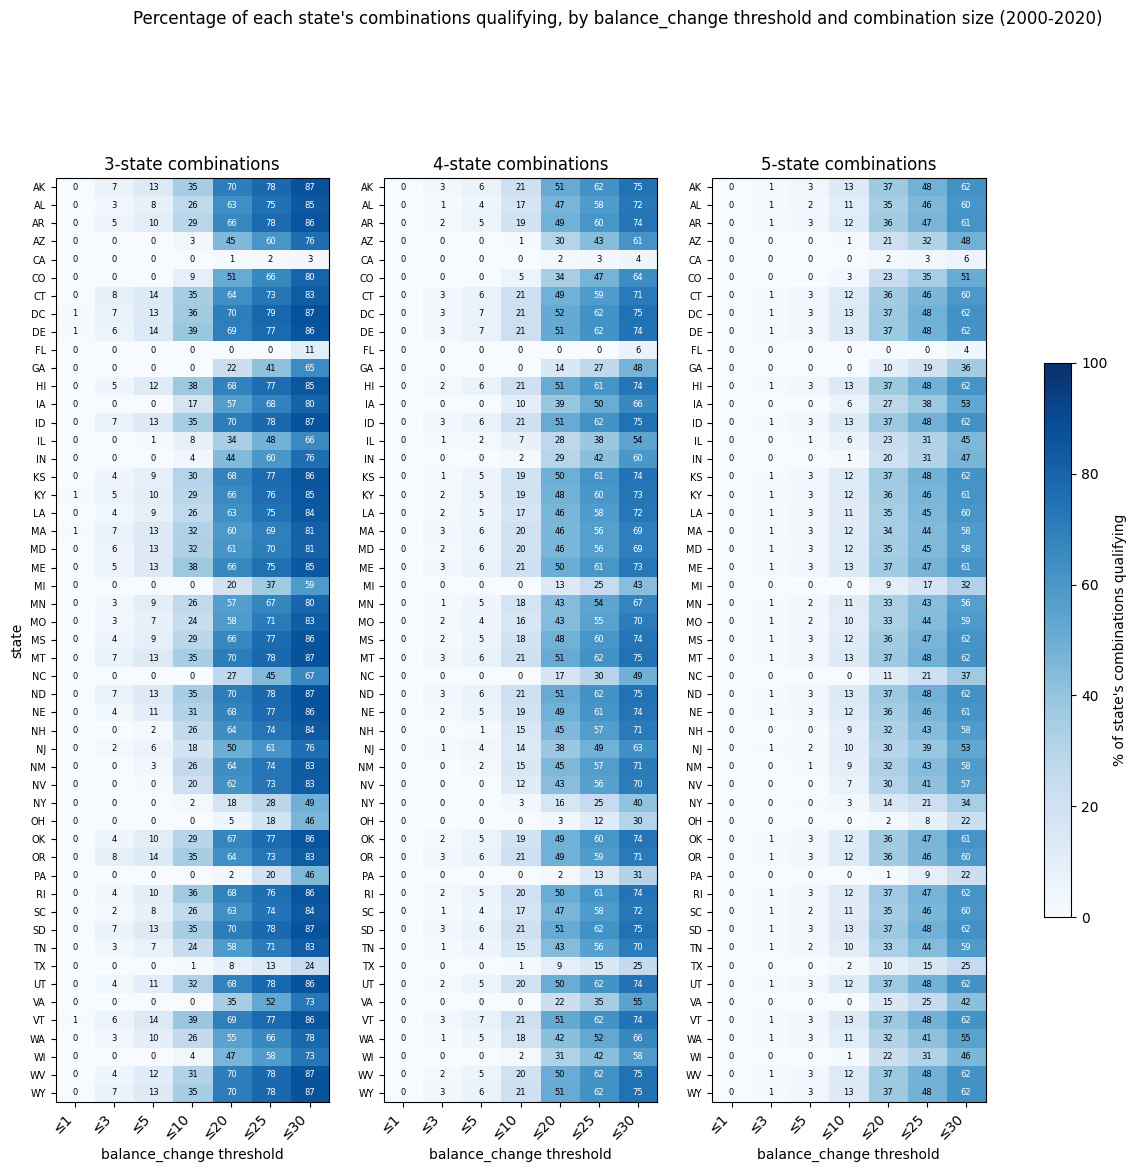

In [9]:
#Build a heatmap for easy visualization of balance change
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Infer the election year range from the same parameters used to build results_df --
# do NOT hardcode it, and do NOT rely on it already being a column in the CSV.
year_min = last_election - 4 * (cycles - 1)
year_max = last_election
year_range_label = f"{year_min}-{year_max}"

df = pd.read_csv(f'state_frequency_by_threshold_and_size_{year_range_label}.csv')
year_range_label = df['year_range_label'].iloc[0]

sizes = sorted(df['combination_size'].unique())
thresholds = sorted(df['threshold'].unique())

fig, axes = plt.subplots(1, len(sizes), figsize=(5 * len(sizes), 12), sharey=False)
if len(sizes) == 1:
    axes = [axes]

for ax, size in zip(axes, sizes):
    sub = df[df['combination_size'] == size]

    # Pivot to states (rows) x thresholds (cols)
    pivot = sub.pivot(index='state', columns='threshold', values='pct_of_states_combinations_qualified')
    pivot = pivot[thresholds]  # enforce threshold column order

    # Sort states ascending by their value at the smallest threshold --
    # puts the hardest-to-qualify states (like FL) at the top
    #pivot = pivot.sort_values(by=thresholds[0], ascending=True)
    pivot = pivot.sort_index(ascending=True)
    im = ax.imshow(pivot.values, aspect='auto', cmap='Blues', vmin=0, vmax=100)

    ax.set_xticks(range(len(thresholds)))
    ax.set_xticklabels([f'\u2264{t}' for t in thresholds], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(f'{size}-state combinations')
    ax.set_xlabel('balance_change threshold')

    # Annotate each cell with its percentage
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            text_color = 'white' if val > 55 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=6, color=text_color)

axes[0].set_ylabel('state')

fig.colorbar(im, ax=axes, shrink=0.6, label='% of state\'s combinations qualifying')
plt.suptitle(f"Percentage of each state's combinations qualifying, by balance_change threshold and combination size ({year_range_label})", y=1.02)
#plt.suptitle("Percentage of each state's combinations qualifying, by balance_change threshold and combination size", y=1.02)
plt.savefig('state_frequency_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

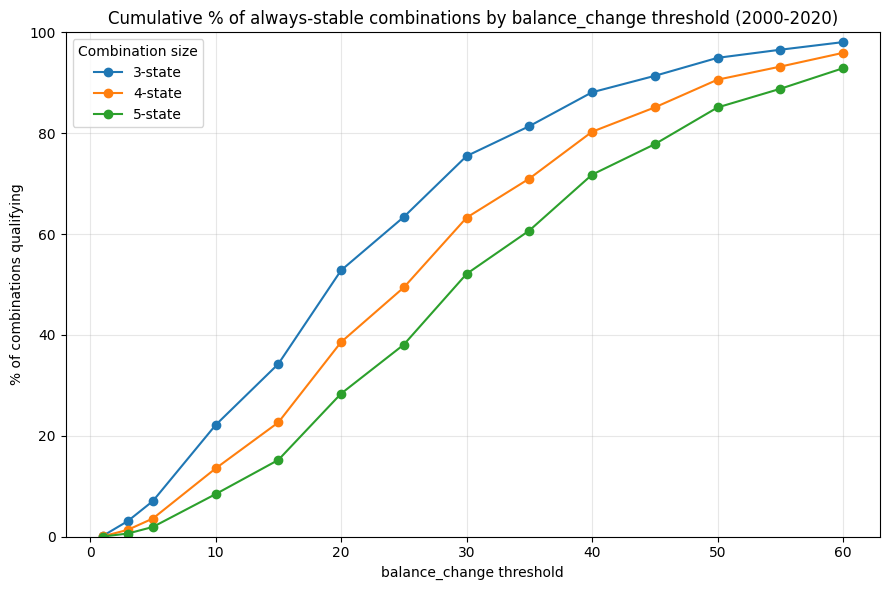

In [10]:
#create chart for cum distribution of balance change
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('always_stable_cumulative_distribution_by_size.csv')

fig, ax = plt.subplots(figsize=(9, 6))

for size, group in df.groupby('size'):
    group = group.sort_values('threshold')
    ax.plot(group['threshold'], group['pct'], marker='o', label=f'{size}-state')

ax.set_xlabel('balance_change threshold')
ax.set_ylabel('% of combinations qualifying')
year_range_label = df['year_range_label'].iloc[0]
ax.set_title(f'Cumulative % of always-stable combinations by balance_change threshold ({year_range_label})')
#ax.set_title('Cumulative % of always-stable combinations by balance_change threshold')
ax.set_ylim(0, 100)
ax.legend(title='Combination size')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('always_stable_cumulative_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Check for any combination
combo = tuple(sorted(['CA', 'TX', 'OH']))  # -> ('CA', 'OH', 'TX')

combo_trajectory = results_df[results_df['combination'] == combo].sort_values('YEAR')

print(f"Balance change by year for {combo}:\n")
print(combo_trajectory[['YEAR', 'vote_balance', 'balance_prop', 'balance_change', 'chg_dem', 'chg_rep']].to_string(index=False))

Balance change by year for ('CA', 'OH', 'TX'):

 YEAR  vote_balance  balance_prop  balance_change  chg_dem  chg_rep
 2004           1.0             3             4.0     -2.0      2.0
 2008          41.0             9            32.0    -16.0     16.0
 2012          35.0             7            28.0    -14.0     14.0
 2016           1.0            11            10.0      5.0     -5.0
 2020           1.0            13            14.0      7.0     -7.0


In [11]:
# =====================================================================
# Out of sample check - How many combinations that met balance_change <= x in EVERY cycle
# from 2000-2020 also meet balance_change <= x in 2024 alone?
# =====================================================================

# Build the 2000-2020 (6-cycle) combination-level results, independent of
# whatever `cycles`/`last_election` cell 1 currently has set
results_2000_2020 = compute_results_df(electiondata, comb_max, cycles=6, last_election=2020)
n_years_hist = results_2000_2020['YEAR'].nunique()

# Build 2024 alone (a single cycle) using the same function --
# cycles=1 with last_election=2024 isolates just that one year
results_2024 = compute_results_df(electiondata, comb_max, cycles=1, last_election=2024)

# Lookup table: each combination's balance_change in 2024 (one row per combo already)
bc_2024 = results_2024.set_index('combination')['balance_change']

thresholds = [1, 3, 5, 10, 20, 25, 30]

records = []
for t in thresholds:
    # Combinations that stayed <= t in EVERY one of the 6 historical cycles
    below = results_2000_2020['balance_change'] <= t
    per_combo = pd.DataFrame({
        'below': below,
        'combination': results_2000_2020['combination'],
        'size': results_2000_2020['size']
    }).groupby('combination', observed=True).agg(
        all_below=('below', 'all'), n=('below', 'size'), size=('size', 'first')
    )
    qualifying_2000_2020 = per_combo[(per_combo['all_below']) & (per_combo['n'] == n_years_hist)]

    # For each of those combinations, check its 2024 balance_change against the same threshold
    bc_2024_for_qualifying = bc_2024.reindex(qualifying_2000_2020.index)
    also_qualifies_2024 = bc_2024_for_qualifying <= t

    n_2000_2020 = len(qualifying_2000_2020)
    n_also_2024 = int(also_qualifies_2024.sum())
    pct = n_also_2024 / n_2000_2020 * 100 if n_2000_2020 else 0

    records.append({'threshold': t, 'size': None, 'qualifying_2000_2020': n_2000_2020,
                     'also_qualifying_2024': n_also_2024, 'pct_also_qualifying_2024': round(pct, 2)})

    # Same thing, broken out by combination size
    for s in sorted(qualifying_2000_2020['size'].unique()):
        subset_idx = qualifying_2000_2020[qualifying_2000_2020['size'] == s].index
        n_size = len(subset_idx)
        also_size = int((bc_2024.reindex(subset_idx) <= t).sum())
        pct_size = also_size / n_size * 100 if n_size else 0
        records.append({'threshold': t, 'size': s, 'qualifying_2000_2020': n_size,
                         'also_qualifying_2024': also_size, 'pct_also_qualifying_2024': round(pct_size, 2)})

summary = pd.DataFrame(records)
print(summary.to_string(index=False))
summary.to_csv('combos_2000_2020_also_stable_2024.csv', index=False)

 threshold  size  qualifying_2000_2020  also_qualifying_2024  pct_also_qualifying_2024
         1   NaN                   394                   256                     64.97
         1   3.0                    26                    21                     80.77
         1   4.0                   108                    73                     67.59
         1   5.0                   260                   162                     62.31
         3   NaN                 18154                 15700                     86.48
         3   3.0                   640                   585                     91.41
         3   4.0                  3360                  3017                     89.79
         3   5.0                 14154                 12098                     85.47
         5   NaN                 55351                 51321                     92.72
         5   3.0                  1467                  1412                     96.25
         5   4.0                  8942     

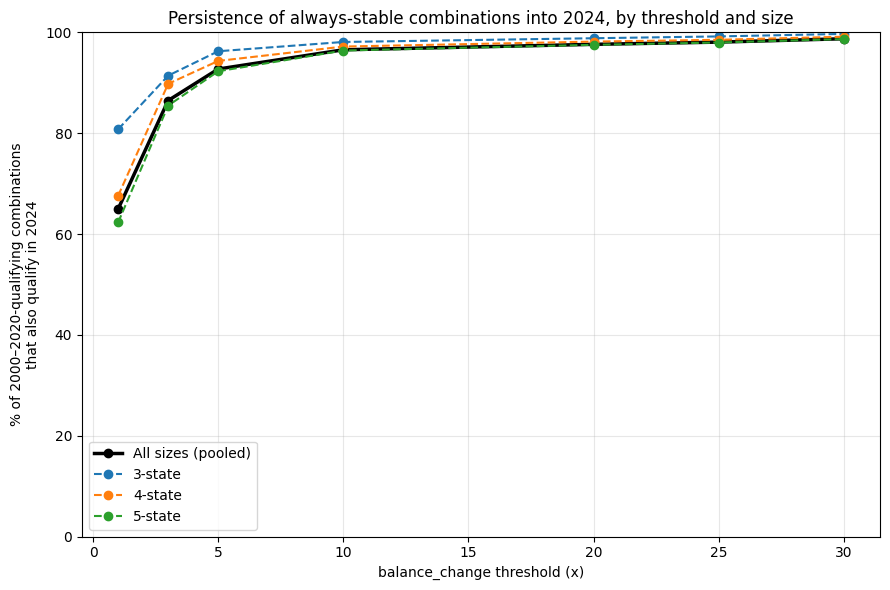

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('combos_2000_2020_also_stable_2024.csv')

pooled = df[df['size'].isna()].sort_values('threshold')
by_size = df[df['size'].notna()].copy()
by_size['size'] = by_size['size'].astype(int)

fig, ax = plt.subplots(figsize=(9, 6))

# Pooled (all sizes combined) line
ax.plot(pooled['threshold'], pooled['pct_also_qualifying_2024'],
        marker='o', linewidth=2.5, color='black', label='All sizes (pooled)')

# One line per combination size
for size, group in by_size.groupby('size'):
    group = group.sort_values('threshold')
    ax.plot(group['threshold'], group['pct_also_qualifying_2024'],
            marker='o', linestyle='--', label=f'{size}-state')

ax.set_xlabel('balance_change threshold (x)')
ax.set_ylabel('% of 2000\u20132020-qualifying combinations\nthat also qualify in 2024')
ax.set_title('Persistence of always-stable combinations into 2024, by threshold and size')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('combos_2000_2020_also_stable_2024.png', dpi=150, bbox_inches='tight')
plt.show()